# Customer Risk Score - Exploratory Data Analysis (EDA)


In [46]:
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv(r"C:\Users\marti\OneDrive\Desktop\credit_risk_dataset.csv")

In [48]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Dataset Overview

In [49]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 32581
Columns: 12


In [50]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


## Missing Values

In [52]:
missing_values = df.isnull().sum()
missing_values
missing_values.sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## Statistical Summary

In [53]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## Numeric Columns

In [54]:
numeric_columns = df.select_dtypes(include="number").columns.drop("loan_status")

numeric_columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='str')

## Histograms

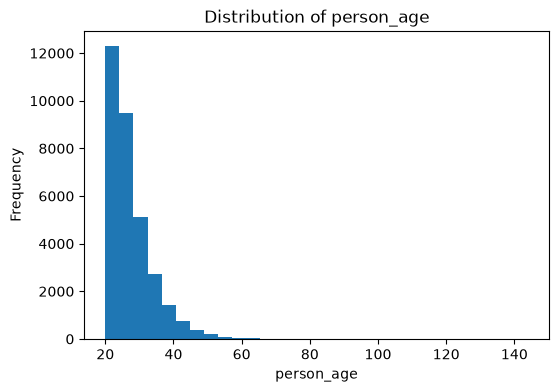

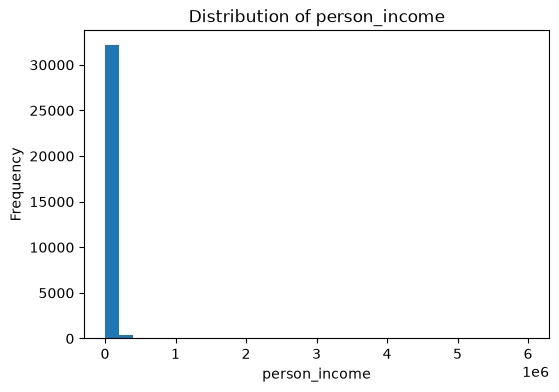

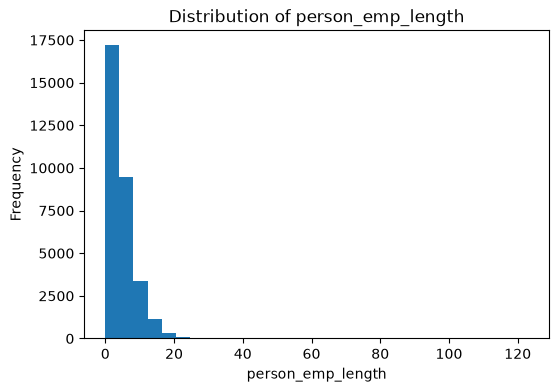

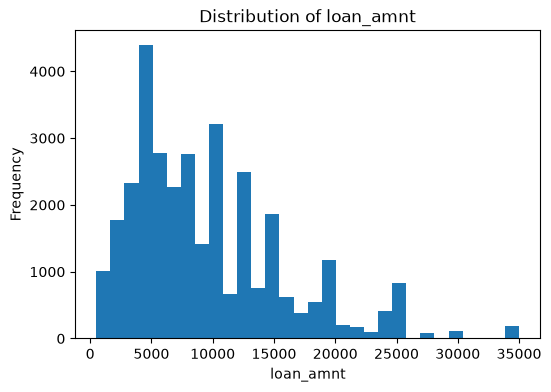

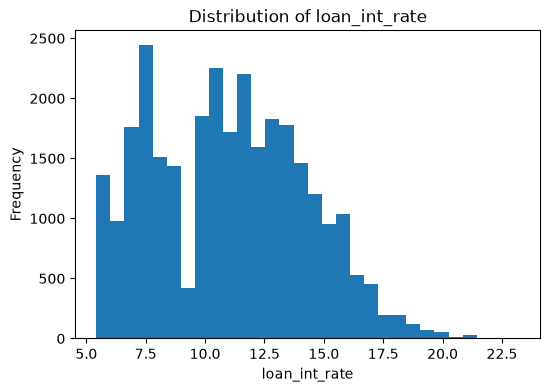

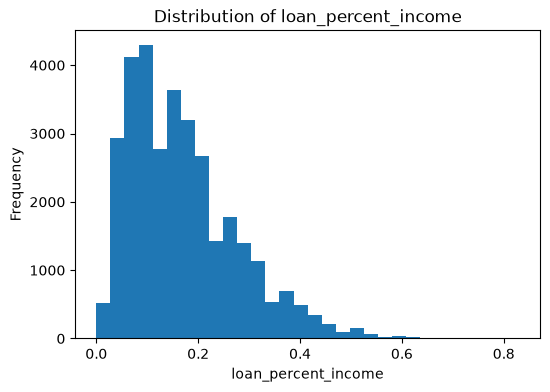

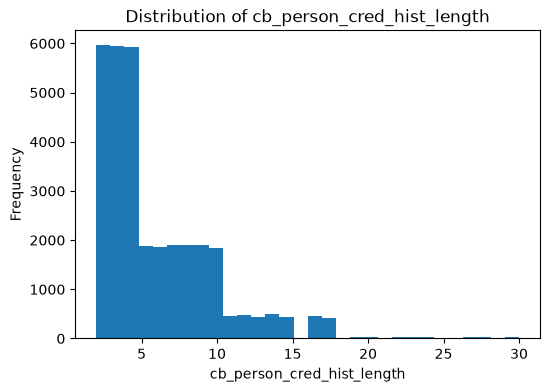

In [55]:
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df[column], bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

## Categorical Analysis

In [56]:
from IPython.display import display

categorical_columns = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

for column in categorical_columns:
    print(f"\n{column}")

    counts_df = (
        df[column]
        .value_counts()
        .reset_index()
    )

    counts_df.columns = [column, "Count"]

    display(counts_df)


person_home_ownership


,person_home_ownership,Count
0,RENT,16446
1,MORTGAGE,13444
2,OWN,2584
3,OTHER,107



loan_intent


,loan_intent,Count
0,EDUCATION,6453
1,MEDICAL,6071
2,VENTURE,5719
3,PERSONAL,5521
4,DEBTCONSOLIDATION,5212
5,HOMEIMPROVEMENT,3605



loan_grade


,loan_grade,Count
0,A,10777
1,B,10451
2,C,6458
3,D,3626
4,E,964
5,F,241
6,G,64



cb_person_default_on_file


,cb_person_default_on_file,Count
0,N,26836
1,Y,5745


## Outlier Detection

C:\Users\marti\AppData\Local\Temp\ipykernel_46712\2634068892.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=True)


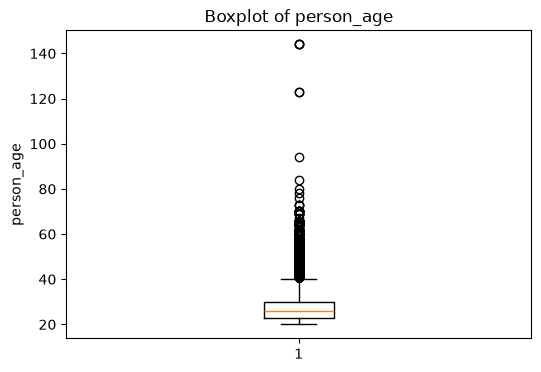

C:\Users\marti\AppData\Local\Temp\ipykernel_46712\2634068892.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=True)


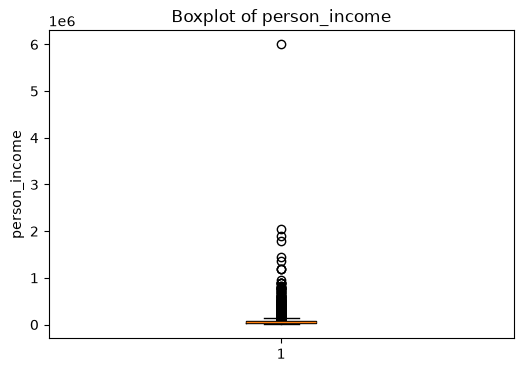

C:\Users\marti\AppData\Local\Temp\ipykernel_46712\2634068892.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=True)


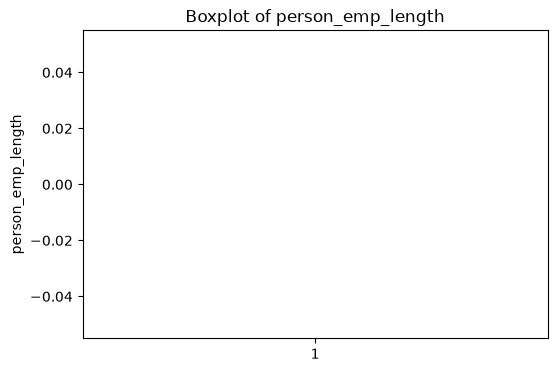

C:\Users\marti\AppData\Local\Temp\ipykernel_46712\2634068892.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=True)


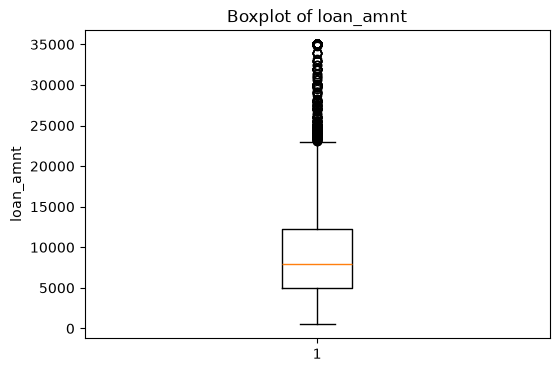

C:\Users\marti\AppData\Local\Temp\ipykernel_46712\2634068892.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=True)


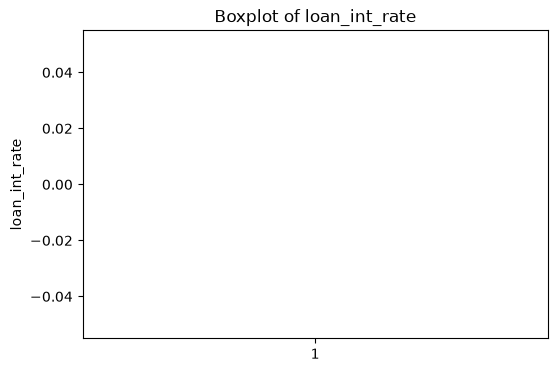

C:\Users\marti\AppData\Local\Temp\ipykernel_46712\2634068892.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=True)


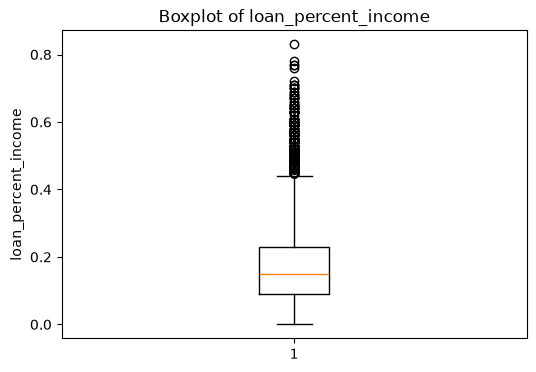

C:\Users\marti\AppData\Local\Temp\ipykernel_46712\2634068892.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=True)


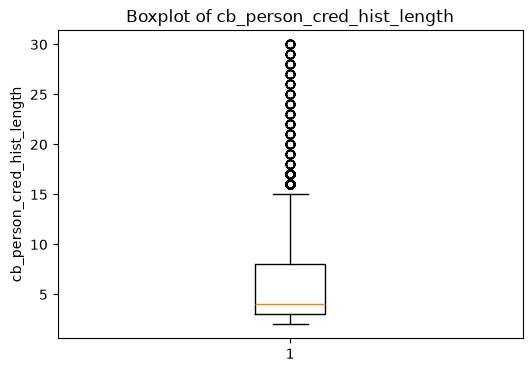

In [57]:
for column in numeric_columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[column], vert=True)
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.show()

In [58]:
outlier_counts = {}

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    outlier_counts[column] = len(outliers)

outlier_counts

{'person_age': 1494,
 'person_income': 1484,
 'person_emp_length': 853,
 'loan_amnt': 1689,
 'loan_int_rate': 6,
 'loan_percent_income': 651,
 'cb_person_cred_hist_length': 1142}

In [59]:
df.groupby("loan_status").mean(numeric_only=True)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
loan_status,,,,,,,
0,27.807129,70804.361559,4.968745,9237.464178,10.435999,0.148805,5.837475
1,27.474676,49125.652223,4.137562,10850.502954,13.060207,0.246889,5.685003


In [60]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [61]:
df["loan_status"].value_counts(normalize=True) * 100

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

# Findings

- The dataset contains numeric and categorical features related to customer credit risk.
- Missing values were identified for later preprocessing.
- Numeric features are mostly right-skewed.
- Outliers were detected, especially in person_age and person_emp_length.
- RENT is the most common home ownership category.
- Most customers have no previous default history.
- Customers with loan_status = 1 have lower average income, higher loan amounts, higher interest rates, and higher loan-to-income ratios.